# Mathematische Grundlagen für Differentialgleichungen

Begleitendes Notebook zu *Angew.Mathe.0MathematischeGrundlagen*: partielle Integration, Taylorpolynome, Eigenwerte und lineare Dynamik.

**Voraussetzungen:** `numpy`, `sympy`, `matplotlib`  
**Arbeitsweise:** Zellen der Reihe nach ausführen und die Kontrollausgaben prüfen.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing()
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True

## 1. Partielle Integration

Wir berechnen $\int x^2e^x\,dx$ symbolisch und prüfen das Ergebnis durch Ableiten.

In [2]:
x = sp.symbols('x', real=True)
f = x**2 * sp.exp(x)
F = sp.integrate(f, x)
kontrolle = sp.simplify(sp.diff(F, x) - f)
print('Stammfunktion:')
display(F)
print('Ableitung minus Integrand =', kontrolle)
assert kontrolle == 0

Stammfunktion:


Ableitung minus Integrand = 0


Die tabellarische partielle Integration liefert $e^x(x^2-2x+2)+C$. SymPy schreibt denselben Ausdruck gegebenenfalls faktorisiert.

## 2. Taylorpolynome und Näherungsfehler

Für $e^x$ vergleichen wir Taylorpolynome verschiedener Ordnung auf $[-1,1]$.

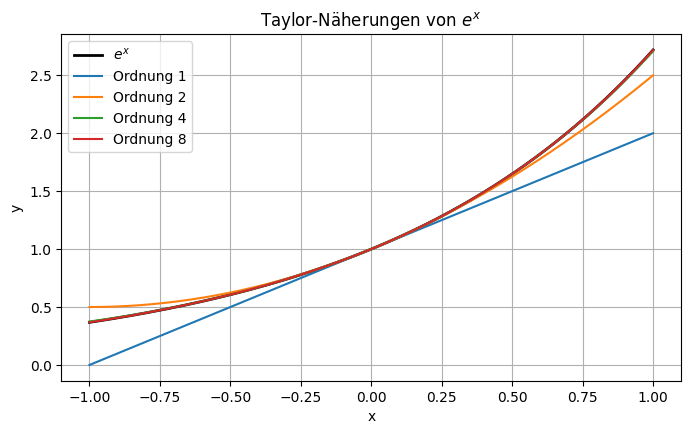

n=1: Näherung=1.100000000000, Fehler=5.171e-03
n=2: Näherung=1.105000000000, Fehler=1.709e-04
n=4: Näherung=1.105170833333, Fehler=8.474e-08
n=8: Näherung=1.105170918076, Fehler=3.109e-15


In [3]:
def taylor_exp(values, order):
    return sum(values**k / sp.factorial(k) for k in range(order + 1))

grid = np.linspace(-1, 1, 400)
plt.plot(grid, np.exp(grid), color='black', linewidth=2, label='$e^x$')
for n in (1, 2, 4, 8):
    approx = np.array(taylor_exp(grid, n), dtype=float)
    plt.plot(grid, approx, label=f'Ordnung {n}')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.title('Taylor-Näherungen von $e^x$');
plt.show()

for n in (1, 2, 4, 8):
    value = float(taylor_exp(0.1, n))
    print(f'n={n}: Näherung={value:.12f}, Fehler={abs(np.exp(0.1)-value):.3e}')

## 3. Eigenwerte, Eigenvektoren und Diagonalisierung

Wir verwenden die Matrix aus dem Skriptbeispiel und kontrollieren $A=PDP^{-1}$.

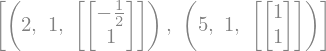

P =


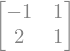

D =


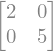

Kontrolle A - P D P^{-1} =


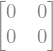

In [4]:
A = sp.Matrix([[4, 1], [2, 3]])
eigen = A.eigenvects()
display(eigen)
P, D = A.diagonalize()
print('P ='); display(P)
print('D ='); display(D)
print('Kontrolle A - P D P^{-1} =')
display(sp.simplify(A - P * D * P.inv()))
assert A == P * D * P.inv()

## 4. Eigenrichtungen in einem stabilen dynamischen System

Für $z'(t)=Az(t)$ bestimmen die Eigenwerte das langfristige Verhalten.

Eigenwerte: [-1. -2.]
Stabil, weil alle Realteile negativ: True


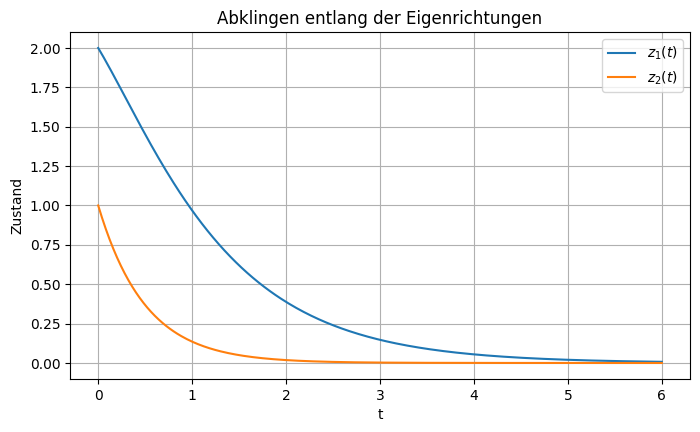

In [5]:
A_stabil = np.array([[-1.0, 1.0], [0.0, -2.0]])
vals, vecs = np.linalg.eig(A_stabil)
print('Eigenwerte:', vals)
print('Stabil, weil alle Realteile negativ:', np.all(np.real(vals) < 0))

t = np.linspace(0, 6, 300)
z0 = np.array([2.0, 1.0])
V = vecs
coeff = np.linalg.solve(V, z0)
traj = np.array([V @ (np.exp(vals * ti) * coeff) for ti in t]).real
plt.plot(t, traj[:, 0], label='$z_1(t)$')
plt.plot(t, traj[:, 1], label='$z_2(t)$')
plt.xlabel('t'); plt.ylabel('Zustand'); plt.legend();
plt.title('Abklingen entlang der Eigenrichtungen'); plt.show()

## Übungen

1. Ersetze $e^x$ durch $\sin x$ und untersuche Taylorordnungen 1, 3, 5 und 7.  
2. Diagonalisiere $\begin{pmatrix}3&0\\2&1\end{pmatrix}$.  
3. Ändere einen Eigenwert von `A_stabil` auf einen positiven Wert und interpretiere den Verlauf.